<a href="https://colab.research.google.com/github/Jhoglund88/TriageFlow/blob/main/TriageFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TriageFlow

Detta är ett program som simulerar ett enkelt digitalt triagesystem. Programmet är utvecklat i utbildningssyfte och är inte avsett för verkliga medicinska bedömningar. Det bedömer patienternas vårdbehov utifrån hur brådskande det är. Användaren registrerar patientens ålder, symptomkategori, symptombeskrivning och smärtnivå.

Programmet:

1. Validerar inmatning från användaren.
2. Identifierar akuta patienter.
3. Skickar patientuppgifterna till en språkmodell (LLM) via ett API.
4. Tar emot och visar språkmodellens bedömning och rekommendation.
5. Sparar patientuppgifterna och språkmodellens svar i en CSV-fil.


## Importer och konfiguration

Här importeras de bibliotek som används i programmet. API-nyckeln hämtas från en ".env-fil" och sparas i variabeln "api_key" för att undvika att nyckeln behöver skrivas ut direkt i koden.


In [8]:
import csv
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

from requests.exceptions import RequestException, Timeout, HTTPError, ConnectionError
from dotenv import load_dotenv

load_dotenv(override=True)

api_key = os.getenv("GROQ_API_KEY")
GROQ_URL = "https://api.groq.com/openai/v1/chat/completions"


## Funktioner

Funktionerna delar upp programmet i mindre delar med olika ansvarsområden. Det gör koden enklare att läsa, testa och återanvända.

- `create_folders()` skapar mapparna som projektet behöver om de ej finns.
- `get_patient_age()` läser in och validerar patientens ålder.
- `get_symptom_category()` låter användaren välja 1 av 4 olika symptomkategorier.
- `get_symptom_description()` kontrollerar att användarens beskrivning är av rimlig längd.
- `get_pain_scale()` läser in och validerar en smärtnivå mellan 0 och 10.
- `save_patients()` sparar patientuppgifter, akut orsak och AI-svar i en CSV-fil.

Vid användarinmatning används loopar för att låta användaren försöka igen vid ogiltig inmatning. `try/except` används för att hantera fel när användaren exempelvis skriver text där heltal förväntas.

In [10]:

def create_folders():
    os.makedirs("data", exist_ok=True)
    os.makedirs("models", exist_ok=True)
    os.makedirs("output", exist_ok=True)

def get_patient_age():
  MAX_AGE = 120

  while True:
          try:
              patient_age = int(input("Ange din ålder (0-120): "))
              if 0 <= patient_age <= MAX_AGE:
                  return patient_age
              else:
                  print(f"[FEL] Ogiltig ålder! Åldern måste vara mellan 0 och {int(MAX_AGE)} år.")
          except ValueError:
              print("[FEL] Du måste ange ålder i siffror (t.ex. 25).")


def get_symptom_category():
  while True:
        try:
            print("\nVälj symptomkategori (1-4):")
            print("1. Luftvägar\n2. Sår/Skador\n3. Infektion/Feber\n4. Övrigt")
            symptom_category = int(input("Ditt val: "))
            if symptom_category == 1:
              return "Luftvägar"
            elif symptom_category == 2:
              return "Sår/Skador"
            elif symptom_category == 3:
              return "Infektion/Feber"
            elif symptom_category == 4:
              return "Övrigt"
            else:
                print("[FEL] Du måste välja ett alternativ mellan 1 och 4.")
        except ValueError:
            print("[FEL] Ange ditt val med en siffra (1, 2, 3 eller 4).")

def get_symptom_description():
  while True:
        symptom_description = input("\nBeskriv dina symptom (minst 5, max 500 tecken): ").strip()
        if len(symptom_description) < 5:
            print("[FEL] Beskrivningen är för kort. Beskriv dina besvär mer noggrant.")
        elif len(symptom_description) > 500:
            print("[FEL] Beskrivningen är för lång. Försök att korta ner den till max 500 tecken.")
        else:
            return symptom_description

def get_pain_scale():
  MAX_PAIN = 10
  while True:
      try:
          pain_scale = int(input(f"\nAnge din smärtgrad på en skala 0-10 (där {int(MAX_PAIN)} är värsta tänkbara smärta): "))
          if 0 <= pain_scale <= MAX_PAIN:
              return pain_scale
          else:
              print(f"[FEL] Ogiltig smärtgrad! Du måste ange en siffra mellan 0 och {int(MAX_PAIN)}.")
      except ValueError:
          print("[FEL] Ange din smärtgrad med en siffra (0-10).")



def save_patients(patients):
    filepath = os.path.join("data", "patients.csv")

    file_exists = os.path.isfile(filepath)

    try:
        with open(filepath, "a", newline="", encoding="utf-8") as file:
            writer = csv.writer(file)

            if not file_exists:

                writer.writerow([
                    "age",
                    "symptom_category",
                    "symptom_description",
                    "pain_scale",
                    "emergency_reason",
                    "ai_response"
            ])

            for patient in patients:
                if patient.is_urgent():
                    emergency_reason = patient.emergency_reason
                else:
                    emergency_reason = ""

                writer.writerow([
                    patient.age,
                    patient.symptom_category,
                    patient.symptom_description,
                    patient.pain_scale,
                    emergency_reason,
                    patient.ai_response
                    

            ])

        return True

    except OSError as e:
        print(f"Fel vid öppning eller skrivning till fil: {e}")

        return False



## OOP - Klasser och arv

Programmet använder klasser för att representera patienter.

`Patient` lagrar patientuppgifter och kontrollerar om patienten är akut.

`EmergencyPatient` ärver från `Patient` och innehåller extra information för patienter som är akuta.

In [3]:
class Patient:
  def __init__(self, age, symptom_category, symptom_description, pain_scale, ai_response=""):
    self.age = age
    self.symptom_category = symptom_category
    self.symptom_description = symptom_description
    self.pain_scale = pain_scale
    self.ai_response = ai_response

  def __str__(self):
    return f"Ålder: {self.age}, Symptom: {self.symptom_category}, Beskrivning: {self.symptom_description}, Smärta: {self.pain_scale}/10"

  def is_urgent(self):
    return self.pain_scale >= 8

class EmergencyPatient(Patient):
  def __init__(self, age ,symptom_category, symptom_description, pain_scale, emergency_reason, ai_response=""):
    super().__init__(age, symptom_category, symptom_description, pain_scale, ai_response)
    self.emergency_reason = emergency_reason

  def get_emergency_reason(self):
    return self.emergency_reason

## AI-integration

Funktionen `analyze_patient` skickar patientuppgifterna till språkmodellen via Groq API och tar emot en bedömning av patientens vårdbehov.

API-anropet innehåller olika sorters felhantering för att undvika att programmet kraschar om anropet misslyckades.


In [4]:





def analyze_patient(patient):
    if not api_key:
        print("[FEL] API-nyckeln saknas. Kontrollera din .env-fil.")
        return None
    prompt = f"""Patientens ålder: {patient.age}
Symptomkategori: {patient.symptom_category}
Symptombeskrivning: {patient.symptom_description}
Smärtskala: {patient.pain_scale}/10

Bedöm patientens vårdbehov.

Svara med:
- urgency_level: ett heltal mellan 1 och 5
- recommendation: vad patienten bör göra
- reason: en kort motivering
"""
    
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    data = {
        "model": "openai/gpt-oss-120b",
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ]
    }
    try:
        response = requests.post(
            GROQ_URL,
            headers=headers,
            json=data,
            timeout=10
        )

        response.raise_for_status()
        result = response.json()
        
        

    except Timeout:
        print("[FEL] Begäran tog för lång tid. Försök igen senare.")
        return None

    except HTTPError as e:
        print(f"[FEL] Ett HTTP-fel uppstod: {e}")
        return None

    except RequestException as e:
        print(f"[FEL] Ett fel uppstod vid begäran: {e}")
        return None

    except ValueError:
        print("[FEL] Kunde inte tolka svaret från servern.")
        return None

    try:
        ai_response = result["choices"][0]["message"]["content"]
    except (KeyError, IndexError, TypeError):
        print("[FEL] API-svaret hade ett oväntat format.")
        return None

    return ai_response


## Huvudprogram

Här registreras patienterna och akuta patienter identifieras. Programmet använder funktionerna och klasserna ovan för att behandla patientuppgifterna.

In [ ]:
create_folders()

print("\n=== TriageFlow ===")
print("Utbildningsprojekt - inte medicinsk rådgivning.\n")

patients = []
emergency_patients = []

while True:
  add_new_patient = input("\nVill du lägga till en ny patient? (j/n): ").strip().lower()
  if add_new_patient == 'j':
    patient_age = get_patient_age()
    symptom_category = get_symptom_category()
    symptom_description = get_symptom_description()
    pain_scale = get_pain_scale()

    patient = Patient(patient_age, symptom_category, symptom_description, pain_scale)

    if patient.is_urgent():
      emergency_reason = input("Vad är ditt akuta symptom? ")
      patient = EmergencyPatient(
          patient_age,
          symptom_category,
          symptom_description,
          pain_scale,
          emergency_reason
      )

      emergency_patients.append(patient)

    patients.append(patient)

    print("\nPatient registrerad!")
  elif add_new_patient == 'n':

    break
  else:
    print("[FEL] Du måste ange 'j' eller 'n'.")



for patient in patients:
    print(patient)

    if patient.is_urgent():
        print(f"Akut symptom: {patient.get_emergency_reason()}")
       

    ai_result = analyze_patient(patient)

    if ai_result is not None:
      patient.ai_response = ai_result
      print(f"\nAI:s bedömning:\n{ai_result}")


if len(patients) == 0:
    print("\nInga patienter att spara.")
elif save_patients(patients):
    print(f"\nKlart! {len(patients)} patienter har sparats i data/patients.csv. {len(emergency_patients)} av dem är akuta patienter.")

    


=== TriageFlow ===
Utbildningsprojekt - inte medicinsk rådgivning.



## Dataanalys och diagram

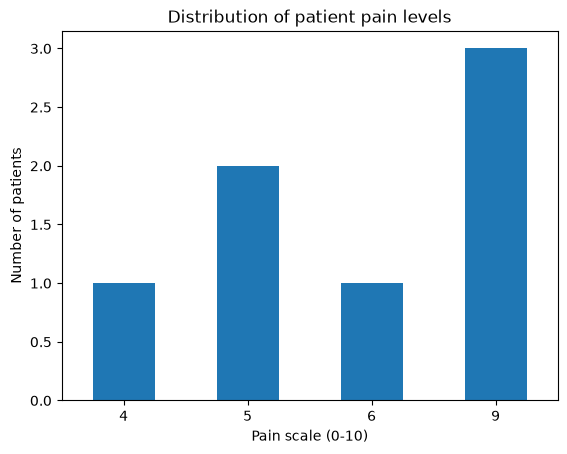

In [6]:
df = pd.read_csv("data/patients.csv")

df["pain_scale"].value_counts().sort_index().plot(kind='bar', rot=0)
plt.xlabel("Pain scale (0-10)")
plt.ylabel("Number of patients")
plt.title("Distribution of patient pain levels")
plt.show()

In [7]:
display(df)

,age,symptom_category,symptom_description,pain_scale,emergency_reason,ai_response
0,4,Sår/Skador,ont i halsen,6,NaN,**urgency_level:** 3 \n\n**recommendation:** ...
1,4,Sår/Skador,väldigt ont i magen,9,extrem värk i mage,- urgency_level: 5 \n- recommendation: Ring 1...
2,55,Sår/Skador,Ramlade och skrapde upp min arm,5,NaN,**urgency_level:** 2 \n\n**recommendation:** ...
3,33,Sår/Skador,ajajaja,4,NaN,- **urgency_level:** 2 \n- **recommendation:*...
4,45,Infektion/Feber,ont i halsen,5,NaN,**urgency_level:** 2 \n\n**recommendation:** ...
5,88,Infektion/Feber,feber och hosta,9,Väldigt höög feber med ihållande hosta,**urgency_level:** 5 \n**recommendation:** Ri...
6,55,Luftvägar,ajajajaj,9,mktkmtont,**urgency_level:** 5 \n\n**recommendation:** ...
